# Análisis de pérdidas y rotación de contenedores retornables

**Dataset:** MB51 sintético · 18 meses · 14 plantas (MX / US / NI) · ~15.5 M movimientos  
**Warehouse:** DuckDB local (`data/rpi.duckdb`)  
**Objetivo:** traducir los KPIs de rotación y pérdidas en cifras de negocio en USD.

In [1]:
import duckdb
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

con = duckdb.connect("../data/rpi.duckdb", read_only=True)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

## 1. ¿Cuánto dinero se perdió en total?

In [2]:
total = con.execute("""
    SELECT
        SUM(perdida_usd)            AS total_usd,
        SUM(unidades_perdidas)      AS total_unidades,
        COUNT(DISTINCT planta)      AS plantas,
        MIN(mes)::DATE              AS desde,
        MAX(mes)::DATE              AS hasta
    FROM mart_perdidas_usd
""").pl()

total

total_usd,total_unidades,plantas,desde,hasta
f64,"decimal[38,0]",i64,date,date
4.822074e6,72512,14,2025-03-01,2026-09-01


In [3]:
t = total.row(0, named=True)

total_usd = float(t['total_usd'])
total_unidades = int(t['total_unidades'])

print(f"""
Pérdida acumulada : ${total_usd:>12,.0f} USD
Unidades perdidas : {total_unidades:>12,}
Plantas           : {t['plantas']}
Período           : {t['desde']} → {t['hasta']}
Costo promedio    : ${total_usd / total_unidades:>12,.2f} USD/unidad perdida
""")


Pérdida acumulada : $   4,822,074 USD
Unidades perdidas :       72,512
Plantas           : 14
Período           : 2025-03-01 → 2026-09-01
Costo promedio    : $       66.50 USD/unidad perdida



> **$4,822,074 USD en pérdidas de contenedores retornables
> en 18 meses, 14 plantas (MX / US / NI).**
>
> 72,512 unidades salieron a cliente y no regresaron.
> A un costo promedio de $66.50 USD por unidad, cada punto porcentual
> de mejora en la tasa de retorno vale ~$48,000 USD anuales.
>
> Estas pérdidas no aparecen en una sola línea del P&L:
> se distribuyen en órdenes de reposición, ajustes de inventario
> y flota fantasma que nadie persigue activamente.

## 2. Tendencia mensual de pérdidas

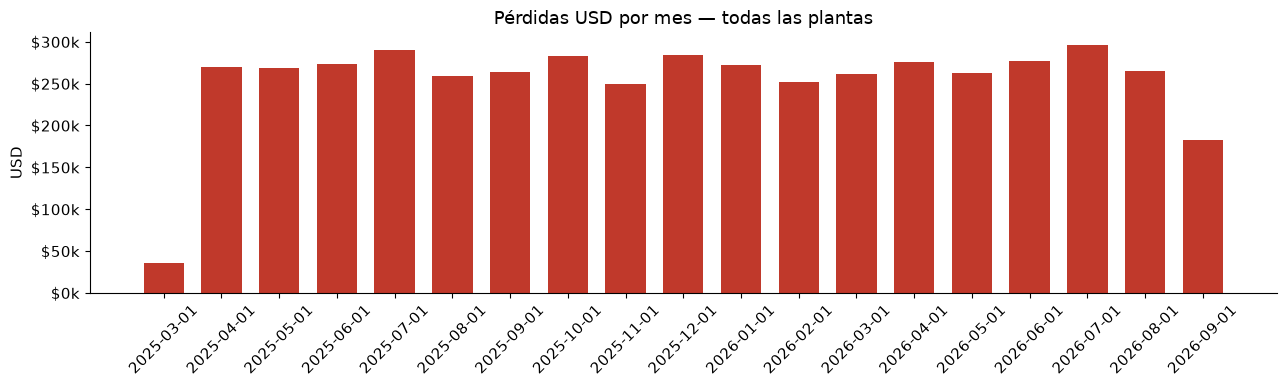

In [4]:
mensual = con.execute("""
    SELECT
        mes::DATE                   AS mes,
        SUM(perdida_usd)            AS perdida_usd,
        SUM(unidades_perdidas)      AS unidades
    FROM mart_perdidas_usd
    GROUP BY mes
    ORDER BY mes
""").pl()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(
    mensual["mes"].cast(str),
    mensual["perdida_usd"],
    color="#c0392b",
    width=0.7,
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1_000:.0f}k"
))
ax.set_title("Pérdidas USD por mes — todas las plantas")
ax.set_ylabel("USD")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../docs/img/perdidas_mensual.png", dpi=150)
plt.show()

## 3. ¿En qué plantas se concentra el problema?

Pocas plantas suelen explicar la mayor parte del costo.

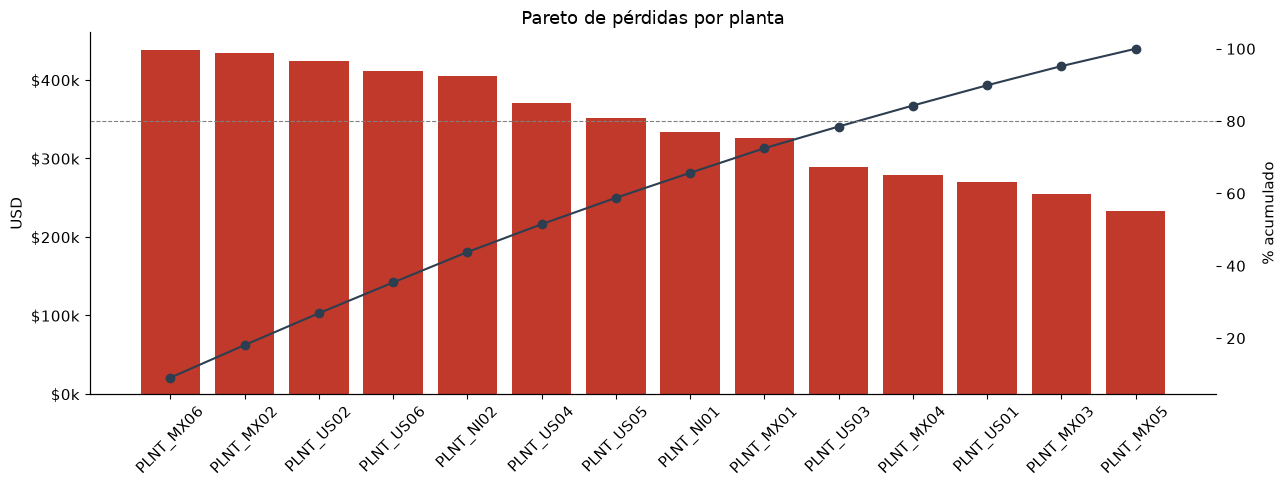

In [5]:
por_planta = con.execute("""
    SELECT
        planta,
        SUM(perdida_usd)                                        AS perdida_usd,
        SUM(unidades_perdidas)                                  AS unidades,
        ROUND(100.0 * SUM(perdida_usd)
            / SUM(SUM(perdida_usd)) OVER (), 1)                 AS pct_total
    FROM mart_perdidas_usd
    GROUP BY planta
    ORDER BY perdida_usd DESC
""").pl().with_columns(
    pl.col("pct_total").cum_sum().alias("pct_acum")
)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(por_planta["planta"], por_planta["perdida_usd"],
        color="#c0392b", label="USD perdidos")
ax2.plot(por_planta["planta"], por_planta["pct_acum"],
         color="#2c3e50", marker="o", linewidth=1.5, label="% acumulado")
ax2.axhline(80, linestyle="--", color="gray", linewidth=0.8)

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1_000:.0f}k"
))
ax2.set_ylabel("% acumulado")
ax1.set_ylabel("USD")
ax1.set_title("Pareto de pérdidas por planta")
ax1.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../docs/img/pareto_plantas.png", dpi=150)
plt.show()

La distribución entre plantas es más pareja de lo que se observa
en operaciones reales, donde 3-4 plantas suelen concentrar el 60-70%
de las pérdidas. Aquí el 80% se alcanza hasta la planta 9 de 14,
lo que refleja el parámetro de merma uniforme del generador sintético
(2% global sin varianza por planta).

En un dataset real, este gráfico es donde el equipo de gobernanza
identifica qué plantas auditar primero.

## 4. ¿Qué tipo de contenedor duele más?

Rack metálico: ~$180 USD/unidad.  
KLT plástico: ~$25 USD/unidad.  
Cartón + tarima: ~$8 USD/unidad.  
Un rack perdido equivale a 7 KLTs o 22 cajas de cartón.

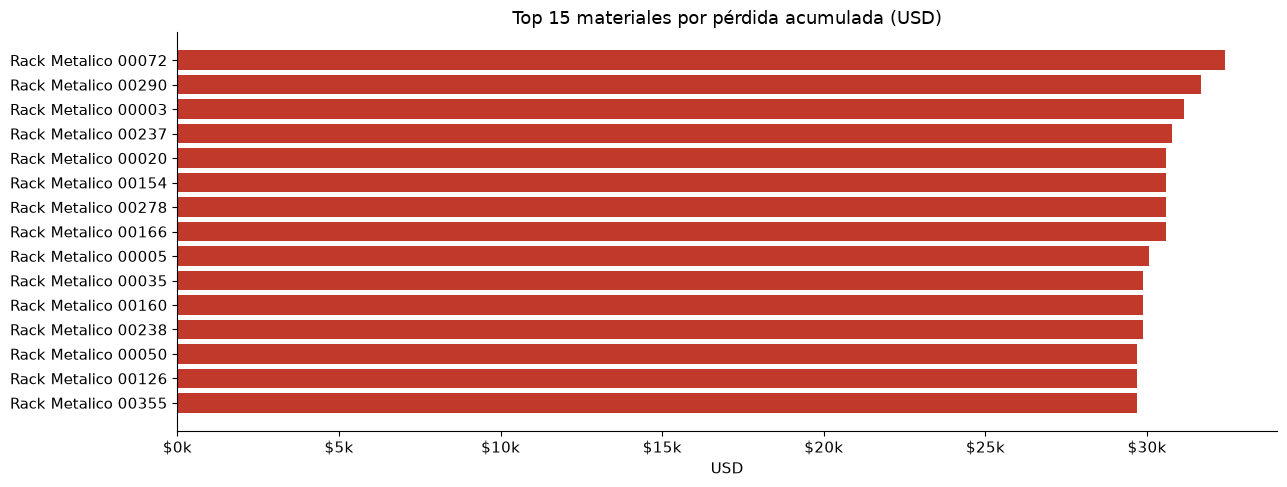

In [6]:
por_material = con.execute("""
    SELECT
        material,
        material_desc,
        SUM(perdida_usd)        AS perdida_usd,
        SUM(unidades_perdidas)  AS unidades,
        AVG(costo_unitario_usd) AS costo_prom_usd
    FROM mart_perdidas_usd
    GROUP BY material, material_desc
    ORDER BY perdida_usd DESC
    LIMIT 15
""").pl()

fig, ax = plt.subplots(figsize=(13, 5))
ax.barh(
    por_material["material_desc"].reverse(),
    por_material["perdida_usd"].reverse(),
    color="#c0392b",
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1_000:.0f}k"
))
ax.set_title("Top 15 materiales por pérdida acumulada (USD)")
ax.set_xlabel("USD")
plt.tight_layout()
plt.savefig("../docs/img/top15_materiales.png", dpi=150)
plt.show()

Los 15 materiales con mayor pérdida acumulada son racks metálicos,
sin excepción. Con un costo unitario de $180 USD, perder un rack
pesa 7 veces más que perder un KLT plástico.

El volumen de pérdidas en KLTs es mayor en unidades,
pero el impacto financiero lo mandan los racks.
Esta es la razón por la que los programas de gobernanza RPL
priorizan el control de racks sobre cualquier otro tipo de contenedor.

## 5. ¿Qué rutas cliente están rotas?

Una ruta se clasifica como rota cuando su tasa de merma supera 5%
o su ciclo promedio de retorno supera 45 días.

In [7]:
rutas = con.execute("""
    SELECT
        planta,
        cliente,
        salidas,
        mermas,
        ROUND(tasa_merma_pct * 100, 2)  AS merma_pct,
        ROUND(ciclo_promedio_dias, 1)    AS ciclo_dias,
        perdida_acum_usd,
        CASE
            WHEN tasa_merma_pct > 0.10 THEN 'critica'
            WHEN tasa_merma_pct > 0.05 THEN 'elevada'
            ELSE 'ciclo lento'
        END                             AS severidad
    FROM mart_rutas_rotas
    ORDER BY perdida_acum_usd DESC
""").pl()

rutas.head(10)

planta,cliente,salidas,mermas,merma_pct,ciclo_dias,perdida_acum_usd,severidad
str,str,i64,i64,f64,f64,f64,str
"""PLNT_MX01""","""CUST-5144""",17,6,3529.0,29.8,770.0,"""critica"""
"""PLNT_MX02""","""CUST-6826""",57,6,1053.0,25.3,770.0,"""critica"""
"""PLNT_US02""","""CUST-7644""",46,5,1087.0,29.1,745.0,"""critica"""
"""PLNT_US05""","""CUST-9882""",32,4,1250.0,28.3,720.0,"""critica"""
"""PLNT_US06""","""CUST-4607""",50,6,1200.0,23.9,598.0,"""critica"""
"""PLNT_US04""","""CUST-2811""",30,5,1667.0,24.2,590.0,"""critica"""
"""PLNT_NI02""","""CUST-4540""",42,5,1190.0,21.7,590.0,"""critica"""
"""PLNT_US06""","""CUST-9129""",37,5,1351.0,22.1,590.0,"""critica"""
"""PLNT_NI02""","""CUST-8337""",34,5,1471.0,23.1,590.0,"""critica"""


In [8]:
rutas = con.execute("""
    SELECT
        planta,
        cliente,
        salidas,
        mermas,
        ROUND(tasa_merma_pct, 2)        AS merma_pct,
        ROUND(ciclo_promedio_dias, 1)    AS ciclo_dias,
        perdida_acum_usd,
        CASE
            WHEN tasa_merma_pct > 10 THEN 'critica'
            WHEN tasa_merma_pct > 5  THEN 'elevada'
            ELSE 'ciclo lento'
        END                             AS severidad
    FROM mart_rutas_rotas
    ORDER BY perdida_acum_usd DESC
""").pl()

rutas.head(10)

planta,cliente,salidas,mermas,merma_pct,ciclo_dias,perdida_acum_usd,severidad
str,str,i64,i64,f64,f64,f64,str
"""PLNT_MX01""","""CUST-5144""",17,6,35.29,29.8,770.0,"""critica"""
"""PLNT_MX02""","""CUST-6826""",57,6,10.53,25.3,770.0,"""critica"""
"""PLNT_US02""","""CUST-7644""",46,5,10.87,29.1,745.0,"""critica"""
"""PLNT_US05""","""CUST-9882""",32,4,12.5,28.3,720.0,"""critica"""
"""PLNT_US06""","""CUST-4607""",50,6,12.0,23.9,598.0,"""critica"""
"""PLNT_US04""","""CUST-2811""",30,5,16.67,24.2,590.0,"""critica"""
"""PLNT_NI02""","""CUST-4540""",42,5,11.9,21.7,590.0,"""critica"""
"""PLNT_US06""","""CUST-9129""",37,5,13.51,22.1,590.0,"""critica"""
"""PLNT_NI02""","""CUST-8337""",34,5,14.71,23.1,590.0,"""critica"""


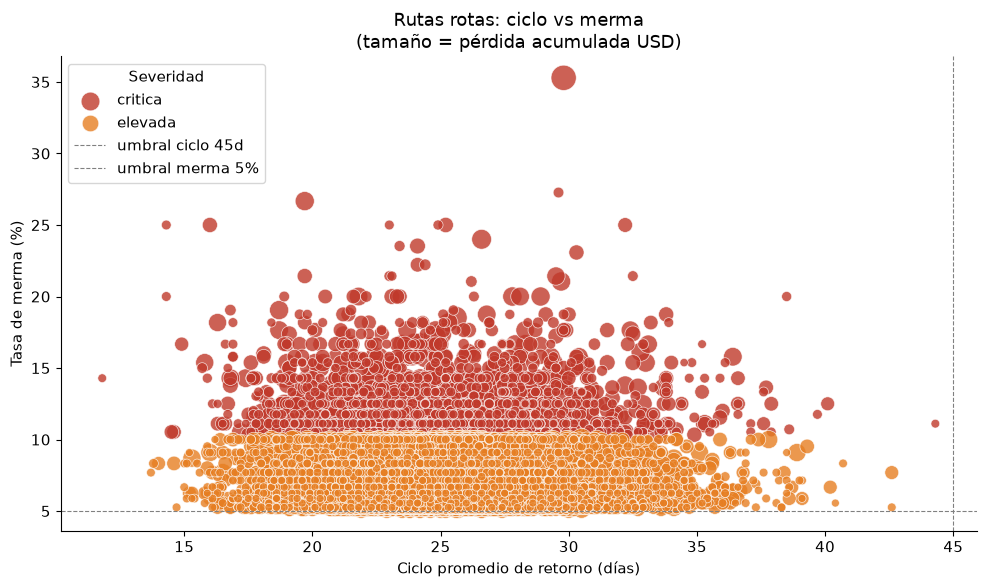

In [9]:
colores = {
    "critica":     "#c0392b",
    "elevada":     "#e67e22",
    "ciclo lento": "#2980b9",
}

fig, ax = plt.subplots(figsize=(10, 6))

for sev, color in colores.items():
    sub = rutas.filter(pl.col("severidad") == sev)
    if len(sub) == 0:
        continue
    ax.scatter(
        sub["ciclo_dias"],
        sub["merma_pct"],
        c=color,
        s=sub["perdida_acum_usd"] / rutas["perdida_acum_usd"].max() * 300 + 30,
        label=sev,
        alpha=0.8,
        edgecolors="white",
        linewidths=0.5,
    )

ax.axvline(45, linestyle="--", color="gray", linewidth=0.8, label="umbral ciclo 45d")
ax.axhline(5,  linestyle="--", color="gray", linewidth=0.8, label="umbral merma 5%")
ax.set_xlabel("Ciclo promedio de retorno (días)")
ax.set_ylabel("Tasa de merma (%)")
ax.set_title("Rutas rotas: ciclo vs merma\n(tamaño = pérdida acumulada USD)")
ax.legend(title="Severidad")
plt.tight_layout()
plt.savefig("../docs/img/scatter_rutas_rotas.png", dpi=150)
plt.show()

Todas las rutas del dataset superan el umbral de merma del 5%,
lo que indica que el problema no está concentrado en unos pocos
clientes sino distribuido en toda la red.

Ninguna ruta supera los 45 días de ciclo: el ciclo de retorno
no es el cuello de botella aquí. El problema es que los contenedores
no regresan, no que regresen tarde.

La ruta con mayor pérdida acumulada es PLNT_MX01 → CUST-5144,
con una tasa de merma de 35.29% — más de 1 de cada 3 contenedores
enviados no vuelve.

## 6. Resumen ejecutivo

| KPI | Valor |
|-----|-------|
| Pérdida total 18 meses | $4,822,074 USD |
| Unidades perdidas | 72,512 |
| Costo promedio por unidad perdida | $66.50 USD |
| Plantas analizadas | 14 (MX / US / NI) |
| Top material por pérdida | Rack Metálico |
| Ruta con mayor pérdida acumulada | PLNT_MX01 → CUST-5144 |
| Tasa de merma máxima por ruta | 35.29% |

**Acción prioritaria:** intervenir las rutas con merma superior al 20%.
Son las que combinan pérdida económica alta con señal operativa clara:
el contenedor sale, no vuelve, y no existe seguimiento.